# Downsampling k-space

The cell below is tagged `#| label: figDownsample`, which is what lets
`02-downsampling.md` embed its output with `:::{figure} #figDownsample`.

TODO: build the figure for this page -- a slider for $R$ and a toggle (or second trace)
between removing lines (aliasing) and zero filling the outer k-space (resolution loss,
no aliasing). See `notebooks/01-central-mask.ipynb` for the pattern this should follow.

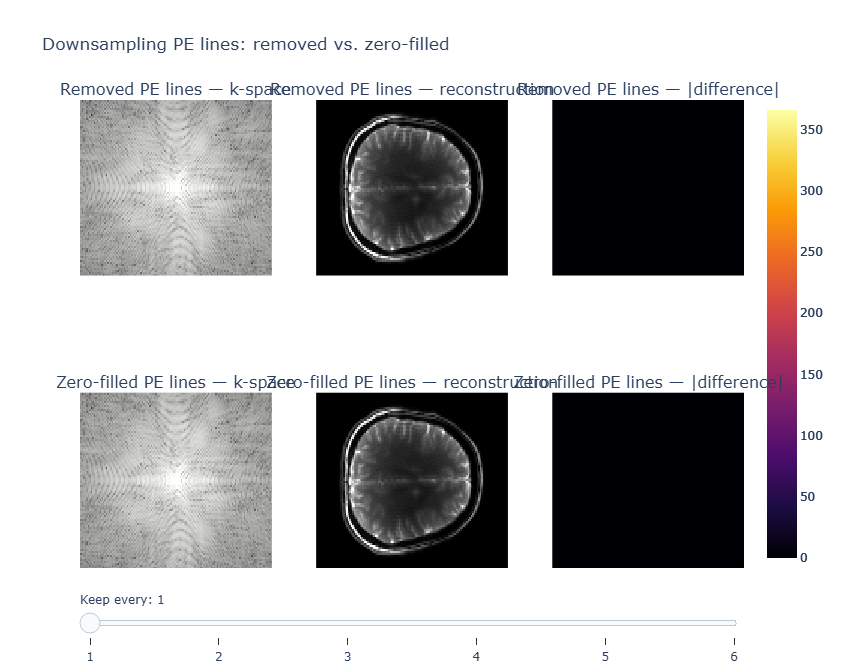

In [6]:
#| label: figDownsample
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "plotly_mimetype+png"
MAG = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz"
PHASE = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz"

mag = nib.load(MAG).get_fdata()[:, :, 0]
phase = nib.load(PHASE).get_fdata()[:, :, 0]
kspace = np.fft.fftshift(np.fft.fft2(mag * np.exp(1j * phase)))
nx, ny = kspace.shape
img_ref = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace)))

# Downsample along the phase-encode direction only (array axis 0, see tblAxes).
# Both methods keep the SAME every-factor-th PE line -- only what happens to the
# skipped lines differs: discarded outright (array shrinks) or zeroed in place
# (array size unchanged).

def downsample_remove(k, factor):
    start = (k.shape[0] // 2) % factor
    return k[start::factor, :]


def downsample_zero(k, factor):
    start = (k.shape[0] // 2) % factor
    out = np.zeros_like(k)
    out[start::factor, :] = k[start::factor, :]
    return out


def pad_to_canvas(array, shape):
    """Nearest-neighbour resize, only so the shrunk 'removed' reconstruction
    can be compared against the full-size reference image."""
    zy, zx = shape[0] / array.shape[0], shape[1] / array.shape[1]
    return zoom(array, (zy, zx), order=0)


factors = [1, 2, 3, 4, 5, 6]

k_log_max = np.percentile(np.log1p(np.abs(kspace)), 99.5)
img_max = np.percentile(img_ref, 99.5)
diff_max = img_max * 0.5

frames = {}
for factor in factors:
    k1 = downsample_remove(kspace, factor)
    img1 = np.abs(np.fft.ifft2(np.fft.ifftshift(k1)))
    img1_disp = pad_to_canvas(img1, (nx, ny)) if factor > 1 else img1
    diff1 = np.abs(img1_disp - img_ref)

    k2 = downsample_zero(kspace, factor)
    img2 = np.abs(np.fft.ifft2(np.fft.ifftshift(k2)))
    diff2 = np.abs(img2 - img_ref)

    frames[factor] = [
        np.log1p(np.abs(k1)), img1_disp, diff1,
        np.log1p(np.abs(k2)), img2, diff2,
    ]

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "Removed PE lines — k-space", "Removed PE lines — reconstruction",
        "Removed PE lines — difference",
        "Zero-filled PE lines — k-space", "Zero-filled PE lines — reconstruction",
        "Zero-filled PE lines — difference",
    ],
)

default = factors[0]
specs = [("gray", 0, k_log_max, False), ("gray", 0, img_max, False), ("inferno", 0, diff_max, True),
         ("gray", 0, k_log_max, False), ("gray", 0, img_max, False), ("inferno", 0, diff_max, True)]
positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]
for z, (colorscale, zmin, zmax, showscale), (row, col) in zip(frames[default], specs, positions):
    fig.add_trace(go.Heatmap(z=z, zmin=zmin, zmax=zmax, colorscale=colorscale, showscale=showscale),
                  row=row, col=col)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.update_layout(
    title="Downsampling PE lines: removed vs. zero-filled",
    height=650, width=950,
    sliders=[dict(
        currentvalue=dict(prefix="Keep every: "),
        active=0,
        steps=[dict(method="restyle", args=[{"z": frames[factor]}, list(range(6))],
                     label=f"{factor}")
               for factor in factors],
    )],
)

fig
